# 05 · Synthesis — Decision & Impact

Pulls Parts A, B, and C together into the numbers a decision-maker needs, with one executive chart per part. The narrative report lives in `reports/stakeholder_report.md`.

- **Part A** — the offer works and pays (causal, significant, profitable).
- **Part B** — the measurement is trustworthy even without an experiment.
- **Part C** — who to target (uplift beats a response model under a budget).

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklift.metrics import uplift_curve

%matplotlib inline
warnings.filterwarnings("ignore")

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "src").exists() else CWD.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src import data_prep as dp
from src import ab_test as ab
from src import causal as cz
from src import uplift as up

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid", context="talk")

MARGIN, COST = 0.30, 0.10
df = dp.add_treatment_flag(dp.load_raw())
treat, control = df[df.treatment == 1], df[df.treatment == 0]
n_t = len(treat)

## Recompute the headline numbers

In [2]:
# Part A: causal effect + economics
conv = ab.two_proportion_ztest(int(treat.conversion.sum()), n_t,
                               int(control.conversion.sum()), len(control))
visit = ab.two_proportion_ztest(int(treat.visit.sum()), n_t,
                                int(control.visit.sum()), len(control))
spend = ab.welch_ttest(treat.spend.values, control.spend.values)
impact = ab.business_impact(spend.diff, n_targeted=n_t, margin=MARGIN, cost_per_send=COST)

# Part B: naive vs corrected on a biased sample
biased = cz.inject_selection_bias(df, seed=42)
true_ate = conv.abs_lift
naive_b = cz.naive_effect(biased, "conversion")["estimate"]
ps_b, _ = cz.fit_propensity(biased)
psm_b = cz.psm_att(biased, "conversion", ps_b)["att"]
ipw_b = cz.ipw_ate(biased, "conversion", ps_b)

# Part C: uplift targeting efficiency
train_df, test_df = up.split_train_test(df, seed=42)
t_model = up.fit_t_learner(train_df, "conversion")
u_t = up.predict_uplift(t_model, test_df, "conversion")
p0, p1 = up.t_learner_p0_p1(t_model, test_df, "conversion")
cap_u = up.capture_fractions(test_df, u_t, "conversion")
cap_r = up.capture_fractions(test_df, p1, "conversion")
qini = up.evaluate(test_df, u_t, "conversion")["qini_auc"]

PER_100K = impact["net_profit_per_customer"] * 100_000
print("CONSOLIDATED SUMMARY")
print(f"A | conversion lift : {conv.abs_lift*100:+.3f} pp (rel {conv.rel_lift:+.0%}), p={conv.p_value:.1e}")
print(f"A | visit lift      : {visit.abs_lift*100:+.3f} pp   spend lift: ${spend.diff:+.3f}")
print(f"A | net/customer    : ${impact['net_profit_per_customer']:.3f}  ROI {impact['roi']:+.0%}")
print(f"A | campaign profit : ${impact['total_net_profit']:,.0f} over {n_t:,} treated")
print(f"A | per 100k custs  : ${PER_100K:,.0f}")
print(f"B | true ATE        : {true_ate*100:+.3f} pp")
print(f"B | naive (biased)  : {naive_b*100:+.3f} pp  (overstates {naive_b/true_ate-1:+.0%})")
print(f"B | PSM / IPW       : {psm_b*100:+.3f} / {ipw_b*100:+.3f} pp (recovered)")
print(f"C | T-learner Qini  : {qini:.3f}")
print(f"C | capture top 30% : uplift {cap_u[0.3]:.0%} vs response {cap_r[0.3]:.0%} vs random 30%")

CONSOLIDATED SUMMARY
A | conversion lift : +0.495 pp (rel +87%), p=4.3e-10
A | visit lift      : +6.088 pp   spend lift: $+0.597
A | net/customer    : $0.079  ROI +79%
A | campaign profit : $3,374 over 42,694 treated
A | per 100k custs  : $7,904
B | true ATE        : +0.495 pp
B | naive (biased)  : +0.704 pp  (overstates +42%)
B | PSM / IPW       : +0.534 / +0.582 pp (recovered)
C | T-learner Qini  : 0.043
C | capture top 30% : uplift 47% vs response 32% vs random 30%


## Executive chart 1 — Part A: the offer works and pays

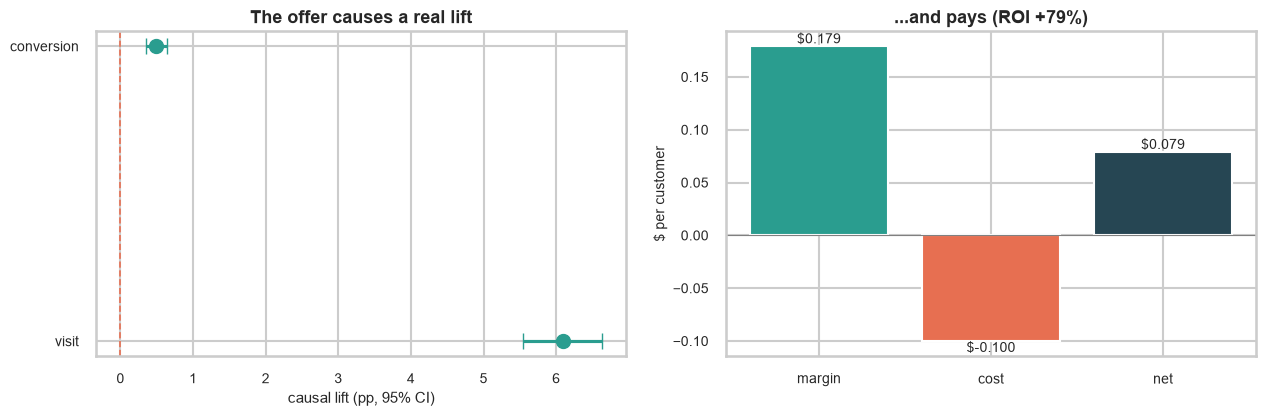

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
# left: causal lifts with 95% CI
rows = [("visit", visit), ("conversion", conv)]
for i, (name, r) in enumerate(rows):
    ax1.errorbar(r.abs_lift*100, i,
                 xerr=[[(r.abs_lift-r.ci_low)*100], [(r.ci_high-r.abs_lift)*100]],
                 fmt="o", color="#2a9d8f", capsize=6, ms=10)
ax1.axvline(0, color="#e76f51", ls="--", lw = 1.2)
ax1.set_yticks(range(len(rows))); ax1.set_yticklabels([n for n, _ in rows], fontsize=11)
ax1.set_xlabel("causal lift (pp, 95% CI)", fontsize=11); ax1.set_title("The offer causes a real lift", fontsize=13, fontweight="bold")
ax1.tick_params(axis='both', labelsize=10)
# right: per-customer economics
labels = ["margin", "cost", "net"]
vals = [impact["incremental_margin_per_customer"], -impact["cost_per_customer"],
        impact["net_profit_per_customer"]]
ax2.bar(labels, vals, color=["#2a9d8f", "#e76f51", "#264653"])
ax2.axhline(0, color="grey", lw=0.8)
for i, v in enumerate(vals):
    ax2.text(i, v, f"${v:.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=10)
ax2.set_ylabel("$ per customer", fontsize=10); ax2.set_title(f"...and pays (ROI {impact['roi']:+.0%})", fontsize=13, fontweight="bold")
ax2.tick_params(axis='both', labelsize=10)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_exec_partA.png", dpi=120, bbox_inches="tight"); plt.show()

## Executive chart 2 — Part B: trustworthy even without an experiment

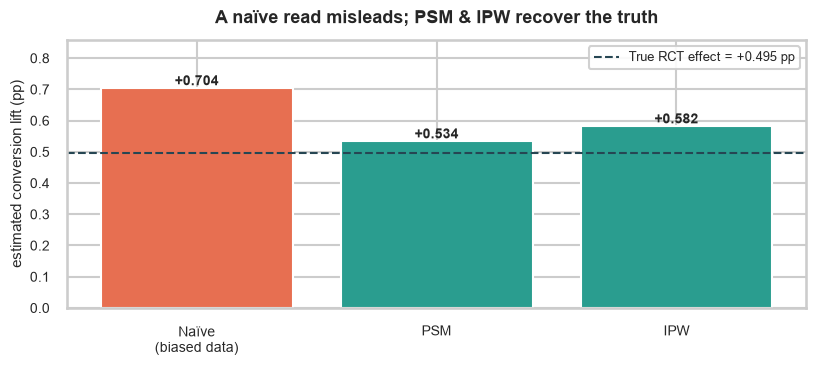

In [4]:
fig, ax = plt.subplots(figsize=(8.5, 4))
labels = ["Naïve\n(biased data)", "PSM", "IPW"]
vals = [naive_b, psm_b, ipw_b]
colors = ["#e76f51", "#2a9d8f", "#2a9d8f"]

bars = ax.bar(labels, [v*100 for v in vals], color=colors)
ax.axhline(true_ate*100, color="#264653", ls="--", lw=1.5, label=f"True RCT effect = {true_ate*100:+.3f} pp")
for i, v in enumerate(vals):
    ax.text(i, v*100, f"{v*100:+.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("estimated conversion lift (pp)", fontsize=11)
ax.set_title("A naïve read misleads; PSM & IPW recover the truth", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis='both', labelsize=10)

ymax = max(vals) * 100
ax.set_ylim(0, ymax * 1.22)

ax.legend(fontsize=9, loc="upper right", framealpha=0.9)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_exec_partB.png", dpi=120, bbox_inches="tight"); plt.show()

## Executive chart 3 — Part C: target by uplift under a budget

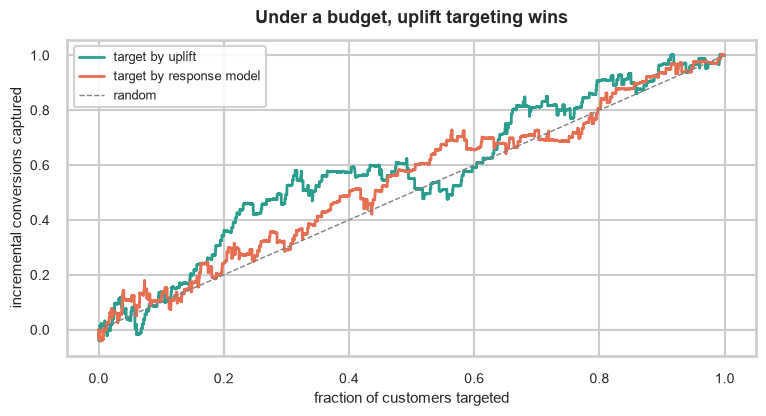

In [5]:
_, yte, tte = up._xyt(test_df, "conversion")
x_u, y_u = uplift_curve(yte, u_t, tte)
x_r, y_r = uplift_curve(yte, p1, tte)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(x_u/x_u[-1], y_u/y_u[-1], color="#2a9d8f", lw=2, label="target by uplift")
ax.plot(x_r/x_r[-1], y_r/y_r[-1], color="#e76f51", lw=2, label="target by response model")
ax.plot([0, 1], [0, 1], ls="--", color="grey", lw=1, label="random")
ax.set_xlabel("fraction of customers targeted", fontsize=11); ax.set_ylabel("incremental conversions captured", fontsize=11)
ax.set_title("Under a budget, uplift targeting wins", fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis='both', labelsize=10)
ax.legend(fontsize=9, loc="upper left", framealpha=0.9)
fig.tight_layout(); fig.savefig(FIG_DIR / "05_exec_partC.png", dpi=120, bbox_inches="tight"); plt.show()

## The decision

**Roll out the offer** — it causes a real, statistically significant, and profitable lift (Part A), a conclusion defensible even without a clean experiment (Part B). With current economics it's profitable for almost everyone, so target broadly; when budget-constrained, rank by predicted uplift (Part C).

Full write-up: `reports/stakeholder_report.md`.